In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

In [2]:
# 패키지 import
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 시각화의 선명도를 높임
%config InlineBackend.figure_format = "retina"

# seaborn 스타일 설정
sns.set(style='white', rc={'figure.figsize':(20,5)})

# 한글설정
plt.rc('font', family='Malgun Gothic') # 윈도우즈
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지


# 다른 폰트를 기본으로 하려면
# import matplotlib.font_manager as fm
# font_file = 'C:/Windows/Fonts/HMKMAMI.TTF'
# font_name = fm.FontProperties(fname=font_file,
#                              # size = 10
#                              ).get_name()
# plt.rc('font',family=font_name)
    
# warning(경고) 안보이게
import warnings
# warnings.filterwarnings(action='default')
warnings.filterwarnings(action='ignore') # 경고 메세지 무시

In [4]:
df = pd.read_csv("C:/ai_x/download/shareData/상가정보_20250331/서울부산상가정보(최종).csv")

# 10. 상권업종대분류명별 상호명의 개수를 도출하고 시각화하기

In [5]:
df['상권업종대분류명'].value_counts()

음식         193508
소매         151969
과학·기술      107216
수리·개인       71012
교육          52404
부동산         30940
시설관리·임대     30466
예술·스포츠      26408
보건의료        20758
숙박          11373
Name: 상권업종대분류명, dtype: int64

In [6]:
df.isna().sum()

상호명          1
상권업종대분류명     0
상권업종중분류명     0
상권업종소분류명     0
시도명          0
시군구명         0
행정동명         0
법정동명         0
대지구분명        0
지번본번지       63
지번주소         0
도로명          0
건물본번지        1
도로명주소        0
경도           0
위도           0
dtype: int64

In [7]:
# 상호명이 결측치인 행
df[df['상호명'].isna()]

,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시도명,시군구명,행정동명,법정동명,대지구분명,지번본번지,지번주소,도로명,건물본번지,도로명주소,경도,위도
548763,NaN,소매,섬유·의복·신발 소매,신발 소매업,부산광역시,부산진구,부전2동,부전동,대지,573.0,부산광역시 부산진구 부전동 573-1,부산광역시 부산진구 중앙대로,717.0,부산광역시 부산진구 중앙대로 717,129.059138,35.155237


In [8]:
# 상권업종대분류명별 상호명수 (pivot_table은 2차원, groupby 1차원이거나 2차원)
result = df.pivot_table(index='상권업종대분류명',
              values='상호명',
              aggfunc='count').sort_values(by='상호명', ascending=False)
# result.columns = ['상호수']
result.rename(columns={'상호명':'상호수'}, inplace=True)
result.head(2)

,상호수
상권업종대분류명,
음식,193508
소매,151968


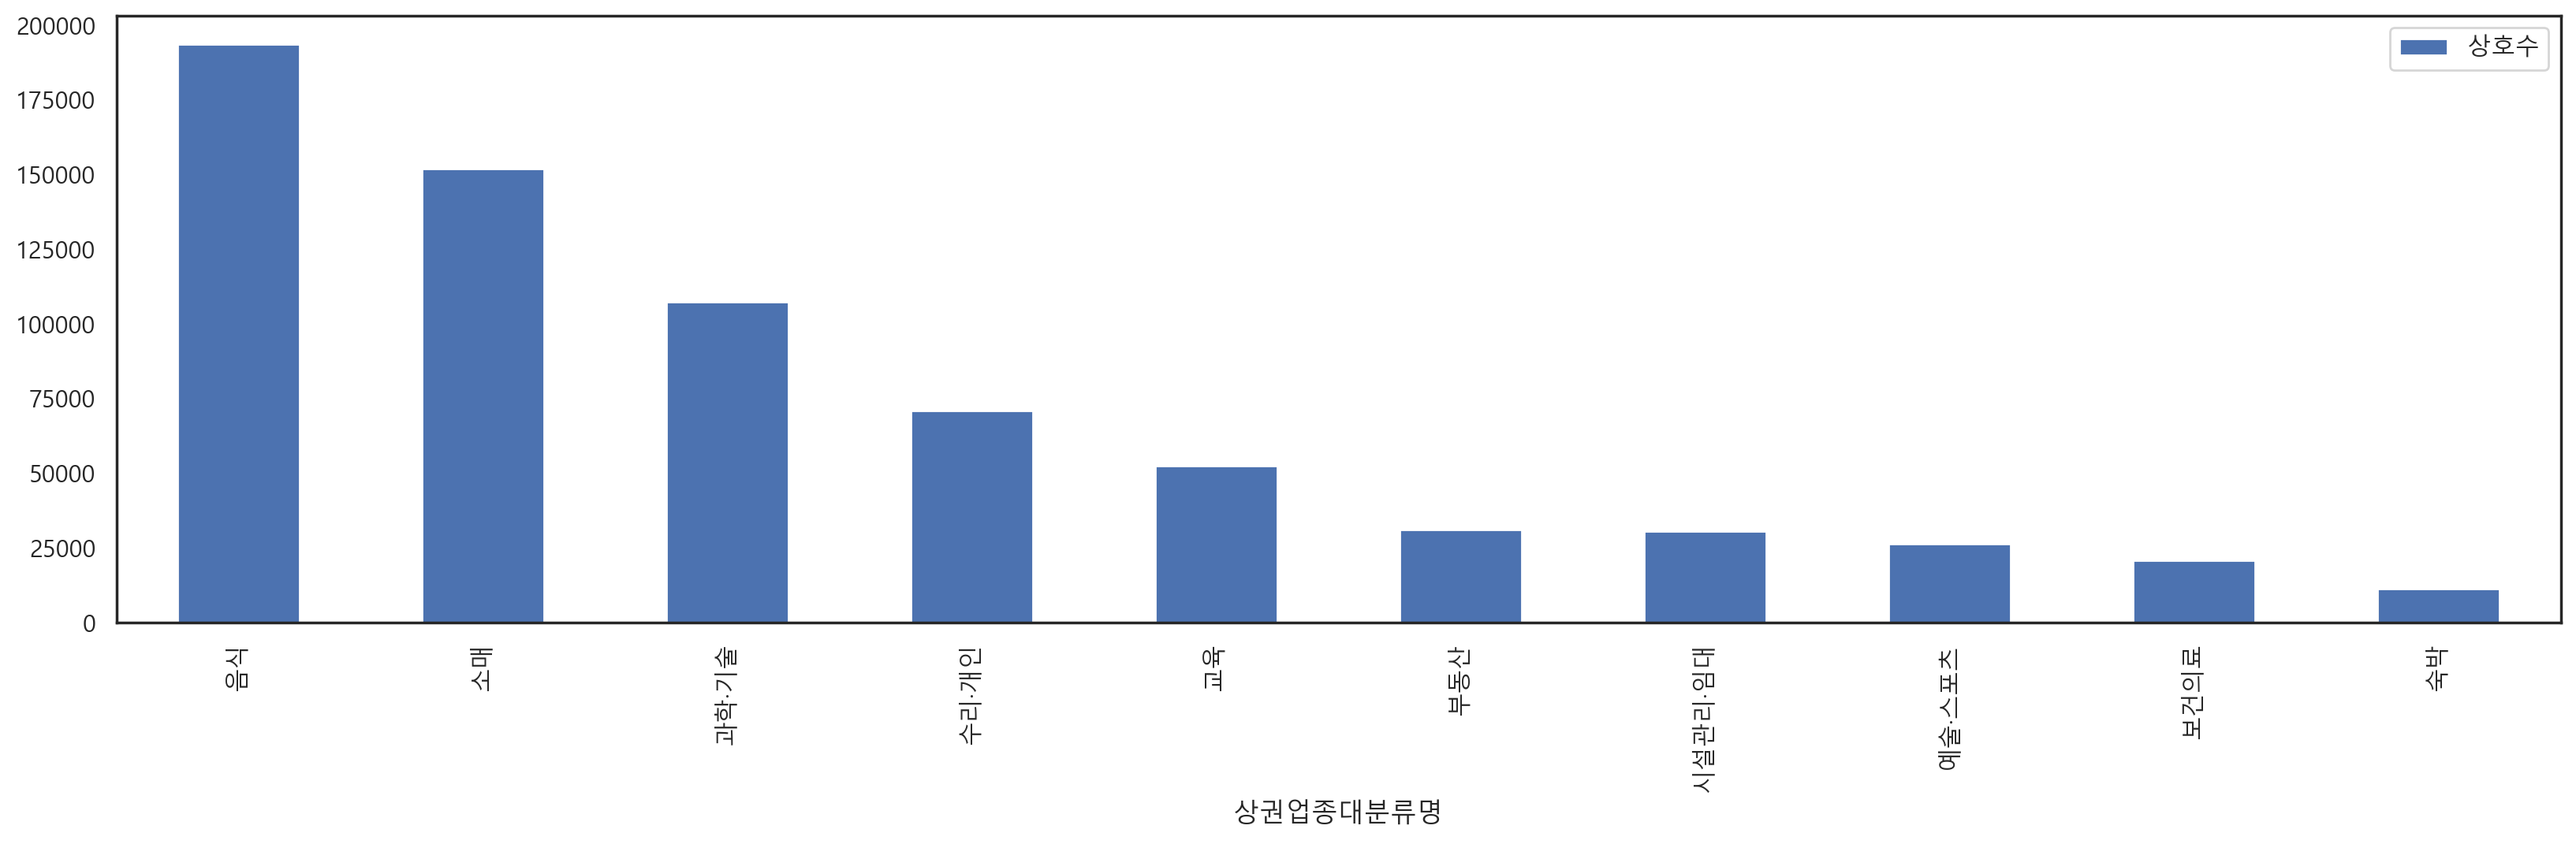

In [9]:
result.plot.bar()
plt.show()

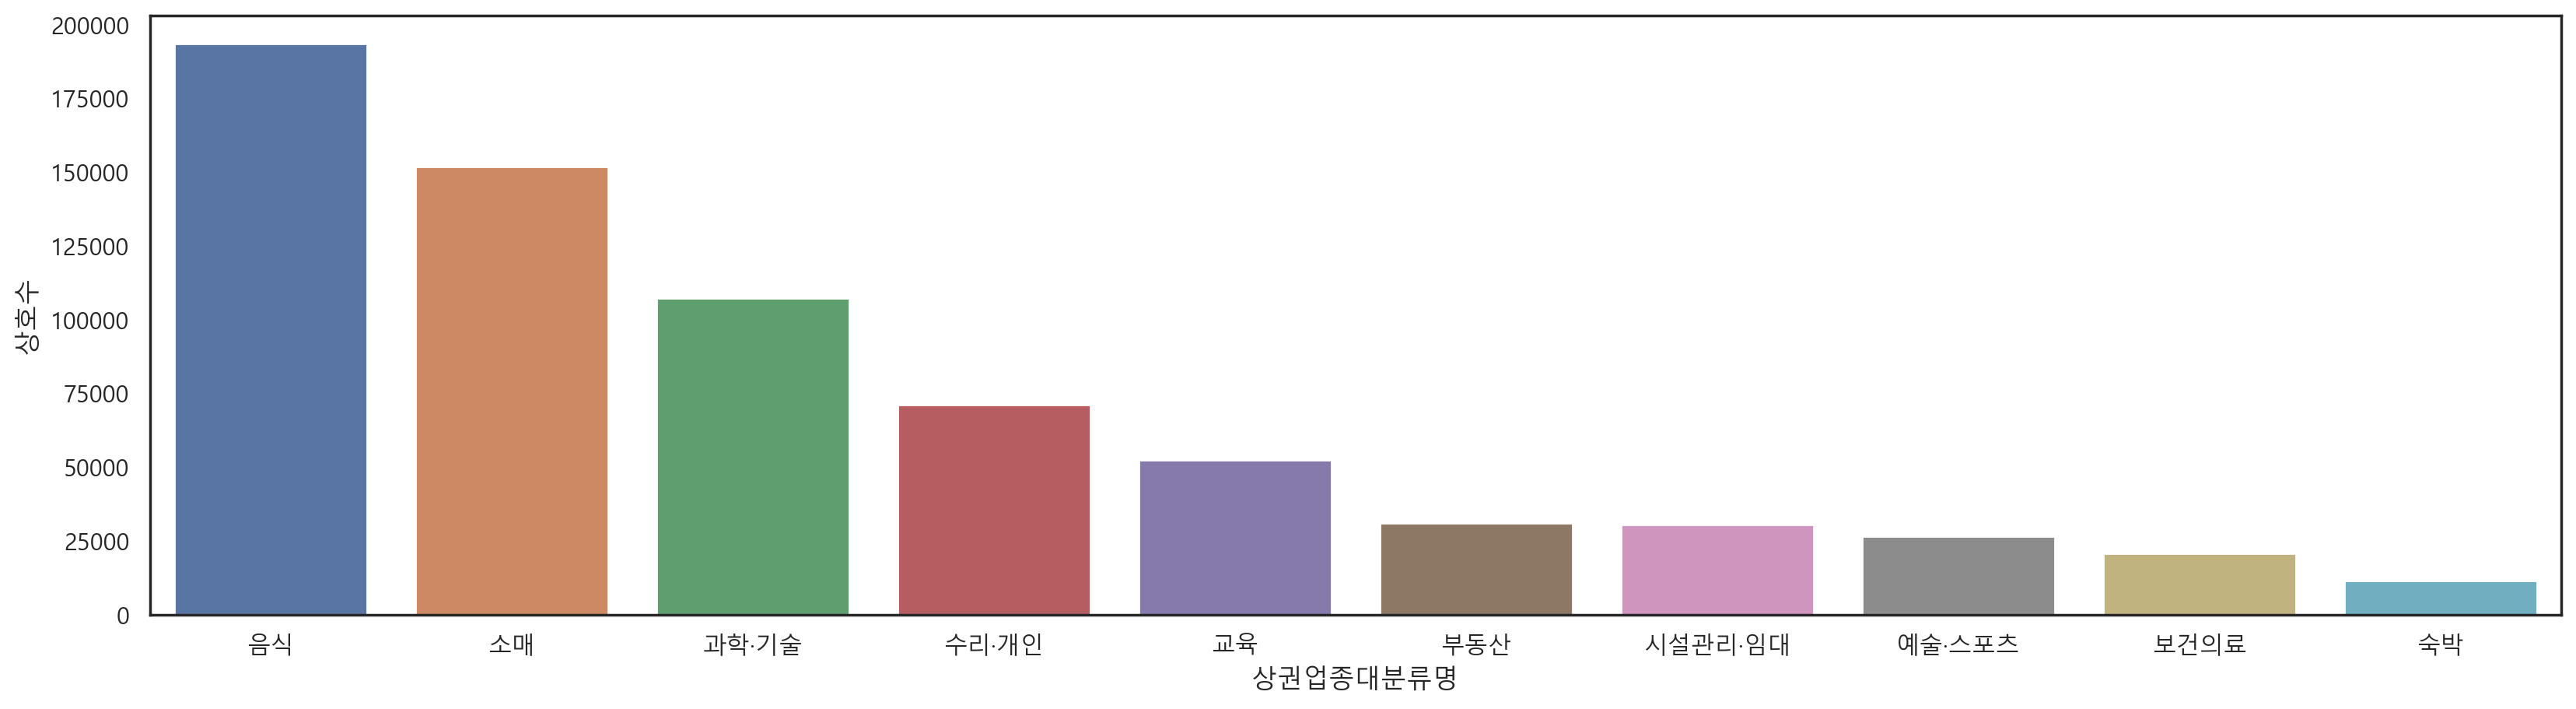

In [10]:
sns.barplot(data=result.reset_index(),
           x='상권업종대분류명',
           y='상호수')
plt.show()

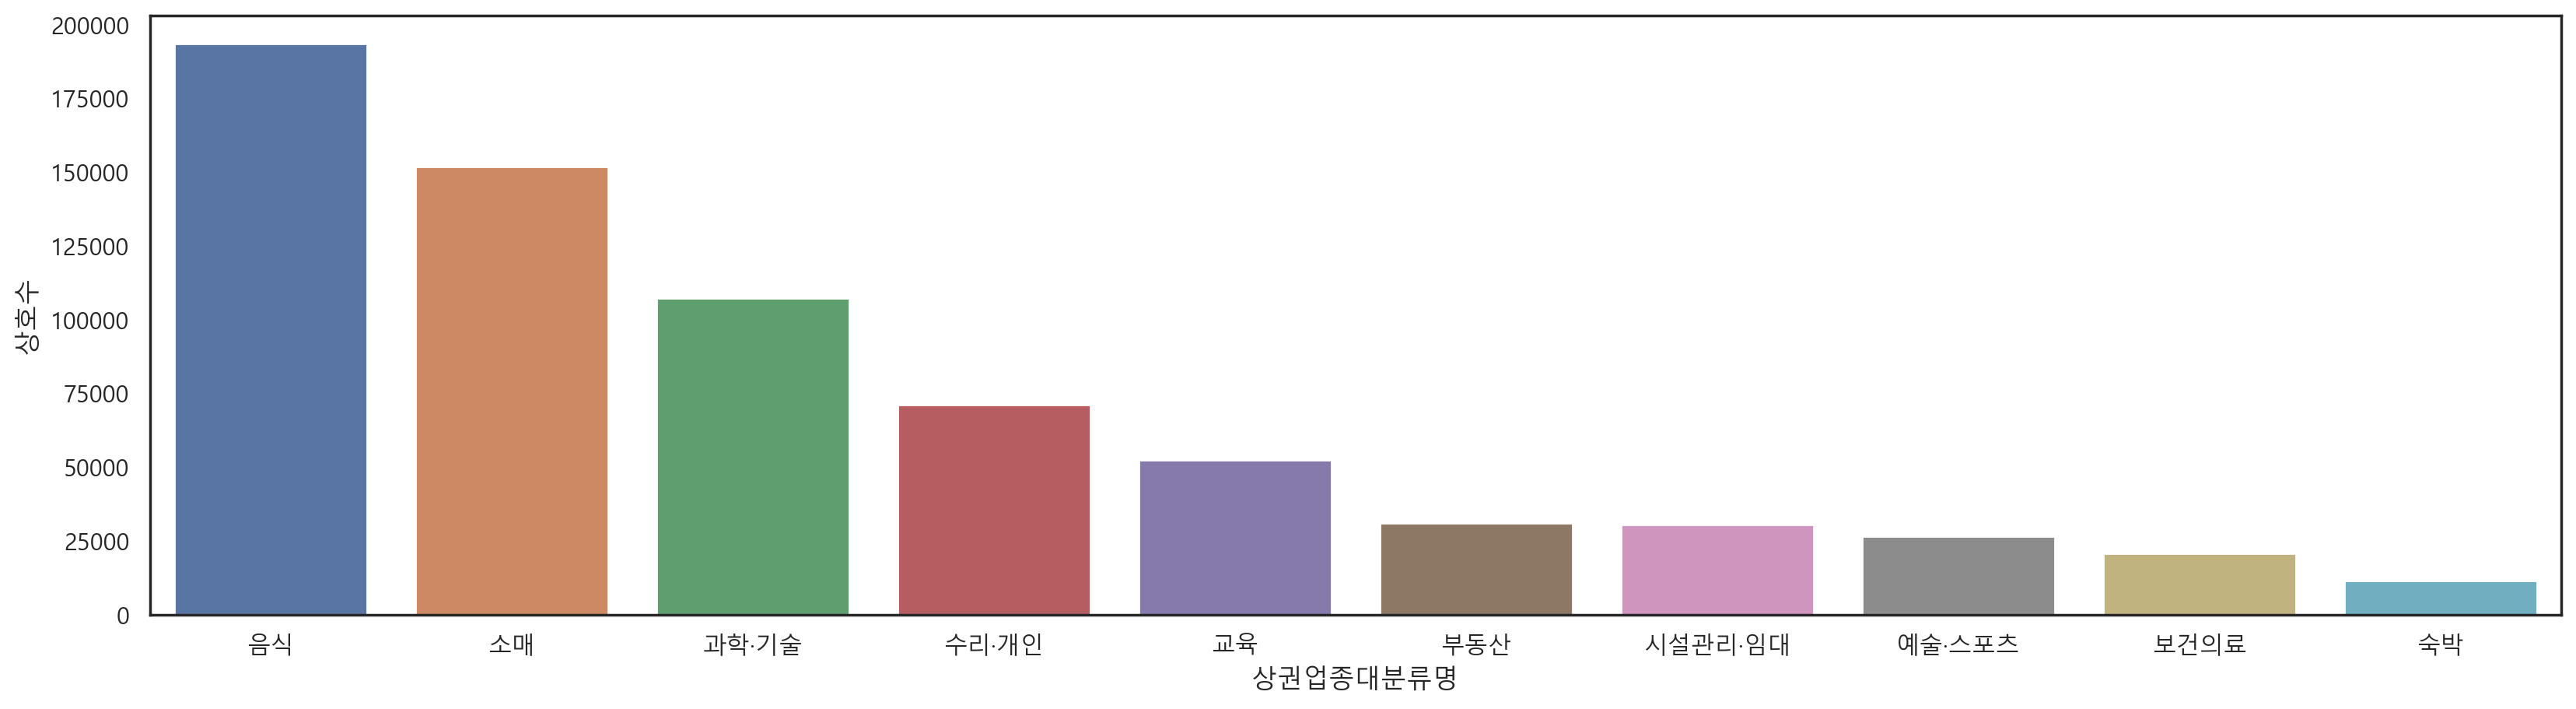

In [11]:
sns.barplot(data=result,
           x=result.index,
           y='상호수')
plt.show()

In [12]:
group = df.groupby(['상권업종대분류명', '상권업종중분류명', '상권업종소분류명'])
len(group)
for grp, val in group:
    print(grp)

('과학·기술', '광고', '광고 대행업')
('과학·기술', '광고', '광고 매체 판매업')
('과학·기술', '광고', '광고물 설계/제작업')
('과학·기술', '광고', '기타 광고 관련 서비스업')
('과학·기술', '광고', '옥외/전시 광고 대행업')
('과학·기술', '기술 서비스', '건물 및 토목 엔지니어링 서비스업')
('과학·기술', '기술 서비스', '건축 설계 및 관련 서비스업')
('과학·기술', '기술 서비스', '기타 엔지니어링 서비스업')
('과학·기술', '기술 서비스', '도시 계획 및 조경 설계 서비스업')
('과학·기술', '기술 서비스', '환경 관련 엔지니어링 서비스업')
('과학·기술', '기타 전문 과학', '번역/통역 서비스업')
('과학·기술', '기타 전문 과학', '사업/무형 재산권 중개업')
('과학·기술', '법무관련 ', '공인노무사')
('과학·기술', '법무관련 ', '기타 법무관련 서비스업')
('과학·기술', '법무관련 ', '법무사')
('과학·기술', '법무관련 ', '변리사')
('과학·기술', '법무관련 ', '변호사')
('과학·기술', '법무관련 ', '행정사')
('과학·기술', '본사·경영 컨설팅', '경영 컨설팅업')
('과학·기술', '사진 촬영', '사진촬영업')
('과학·기술', '수의', '동물병원')
('과학·기술', '시장 조사', '시장 조사 및 여론 조사업')
('과학·기술', '인쇄·제품제작', '명함/간판/광고물 제작')
('과학·기술', '전문 디자인', '시각 디자인업')
('과학·기술', '전문 디자인', '인테리어 디자인업')
('과학·기술', '전문 디자인', '제품 디자인업')
('과학·기술', '전문 디자인', '패션/섬유/기타 전문 디자인업')
('과학·기술', '회계·세무', '공인회계사')
('과학·기술', '회계·세무', '기타 회계 관련 서비스업')
('과학·기술', '회계·세무', '세무사')
('교육', '교육 지원', '교육컨설팅업

# 11. 상권업종대분류명이 음식인 서브셋을 이용한 분석
## ① “상권업종대분류명”이 음식인 서브셋을 변수 df_food에 할당하고 확인